## Actividad 3_15: Uso de KMeans para clasificación de clientes
<div style="border-style:groove;border-width:thin;padding:10px">
En este ejercicio vamos a utilizar KMeans para segmetar o clasificar a un grupo de clientes. En este caso se trata de los clientes de una empresa que vende una gran variedad de cosas. Vamos a utilizar un dataset de una campaña de márketing de una empresa que contiene datos de sus clientes. Estos datos son muy variados. Van desde la fecha de nacimiento hasta lo que han gastado en fruta pasando por el estado civil. 
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
1. Cargamos el dataset.
</div>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("marketing_campaign.csv",sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


<div style="border-style:groove;border-width:thin;padding:10px">
2. Borra la columna ID, ya que no nos aporta nada para segmentar los clientes. Cambia la Columna 'Year_Birth' por una con la edad de cada cliente. Pinta un gráfico de la distribución de edad. Puedes usar sns.violinplot para hacerlo. Consulta la documentación. Es una herramienta sencilla para pintar la distribución de una población por edad.
</div>

In [4]:
df = df.drop(columns=["ID", "Dt_Customer"])

In [5]:
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [6]:
from datetime import datetime

edades = []

for index, row in df.iterrows():
    if pd.notna(row['Year_Birth']):
        edad = datetime.now().year - int(row['Year_Birth'])
        edades.append(edad)
    else:
        edades.append(None)

df['Edad'] = edades

In [7]:
df = df.drop(columns=["Year_Birth"])

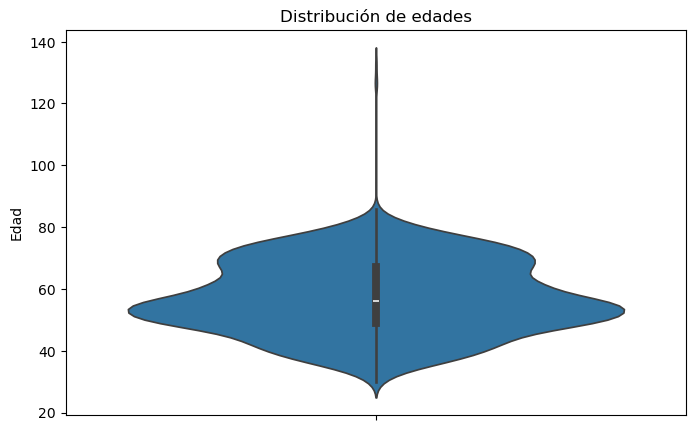

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.violinplot(y=df['Edad'])
plt.title('Distribución de edades')
plt.ylabel('Edad')
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
3. ¿Ves algo raro en la distribución? Elimina los datos que consideres que deben ser eliminados y vuelve a pintar la distribución por edad.
</div>

In [9]:
# df = df[df["Edad"] <= 90]
df = df.drop(df[df["Edad"] > 90].index)

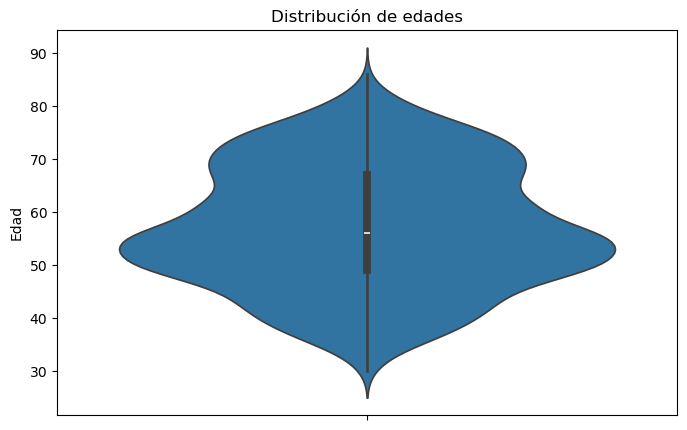

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.violinplot(y=df['Edad'])
plt.title('Distribución de edades')
plt.ylabel('Edad')
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
4. Pinta un gráfico de barras (sns.barplot) con el número de individuos por nivel educativo. Puedes usar también  df.Education.value_counts().
</div>

In [11]:
df["Education"].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

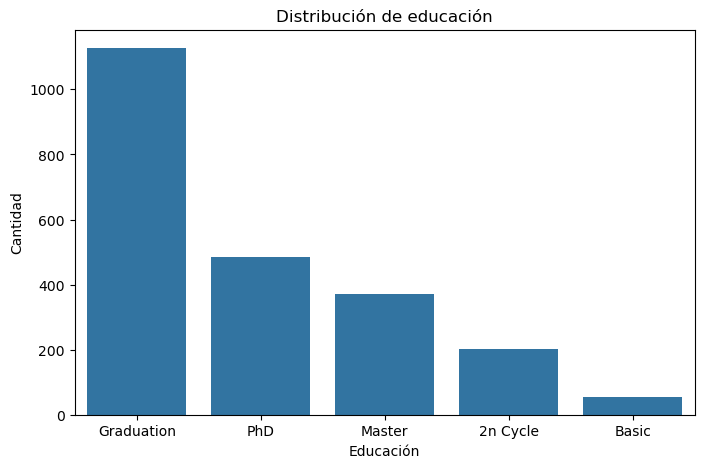

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df['Education'].value_counts().index, y=df['Education'].value_counts().values)
plt.title('Distribución de educación')
plt.xlabel('Educación')
plt.ylabel('Cantidad')
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
5. Pinta ahora un gráfico de barras del sueldo medio por nivel educativo.
</div>

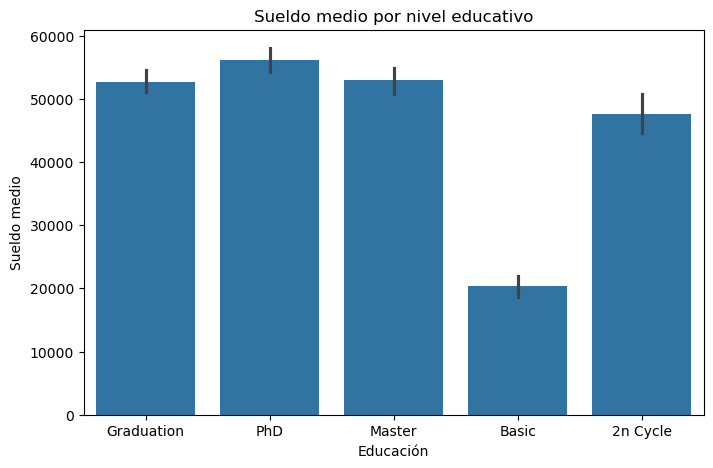

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df['Education'], y=df['Income'])
plt.title('Sueldo medio por nivel educativo')
plt.xlabel('Educación')
plt.ylabel('Sueldo medio')
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
6. Pinta un gráfico de barras del sueldo por tramos de edades de 20 en 20 años.
</div>

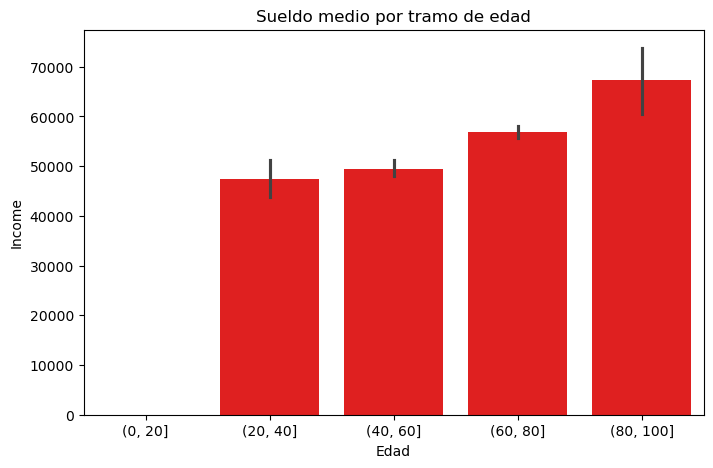

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x=pd.cut(df['Edad'], bins=range(0, 101, 20)), y=df['Income'], color="red")
plt.title('Sueldo medio por tramo de edad')
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
7. Cambia las columnas categóricas por valores numéricos (con el método que prefieras) y elimina los valores nulos (recuerda que se hace con dropna).
</div>

In [15]:
df = pd.get_dummies(data=df, dtype=int)

In [16]:
df.shape

(2237, 38)

In [17]:
df.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Edad', 'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD', 'Marital_Status_Absurd',
       'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO'],
      dtype='object')

In [18]:
df.isnull().sum()

Income                     24
Kidhome                     0
Teenhome                    0
Recency                     0
MntWines                    0
MntFruits                   0
MntMeatProducts             0
MntFishProducts             0
MntSweetProducts            0
MntGoldProds                0
NumDealsPurchases           0
NumWebPurchases             0
NumCatalogPurchases         0
NumStorePurchases           0
NumWebVisitsMonth           0
AcceptedCmp3                0
AcceptedCmp4                0
AcceptedCmp5                0
AcceptedCmp1                0
AcceptedCmp2                0
Complain                    0
Z_CostContact               0
Z_Revenue                   0
Response                    0
Edad                        0
Education_2n Cycle          0
Education_Basic             0
Education_Graduation        0
Education_Master            0
Education_PhD               0
Marital_Status_Absurd       0
Marital_Status_Alone        0
Marital_Status_Divorced     0
Marital_St

In [19]:
df = df.dropna()
df.isna().sum()

Income                     0
Kidhome                    0
Teenhome                   0
Recency                    0
MntWines                   0
MntFruits                  0
MntMeatProducts            0
MntFishProducts            0
MntSweetProducts           0
MntGoldProds               0
NumDealsPurchases          0
NumWebPurchases            0
NumCatalogPurchases        0
NumStorePurchases          0
NumWebVisitsMonth          0
AcceptedCmp3               0
AcceptedCmp4               0
AcceptedCmp5               0
AcceptedCmp1               0
AcceptedCmp2               0
Complain                   0
Z_CostContact              0
Z_Revenue                  0
Response                   0
Edad                       0
Education_2n Cycle         0
Education_Basic            0
Education_Graduation       0
Education_Master           0
Education_PhD              0
Marital_Status_Absurd      0
Marital_Status_Alone       0
Marital_Status_Divorced    0
Marital_Status_Married     0
Marital_Status

<div style="border-style:groove;border-width:thin;padding:10px">
    <p>Ahora vamos a implementar el <b>METODO DEL CODO</b>. Este método consiste en hacer el método KMeans con distintos números de clusters (k). Después se calcula la suma de los Errores Cuadráticos Medios en cada Cluster (WCSS). Se pinta la gráfica de los WCSS para cada valor de k y te quedas con el valor del "codo", es decir, a partir del cual el WCSS baja bastante despacio.</p>
    <p>Los pasos serían los siguientes:</p>
    <ol>
        <li>Realiza el KMeans con valores de k de 0 a 10 o 15, por ejemplo.</li>
        <li>Guarda el dato kmeans.inertia_ para cada valor de k en una lista (este valor se corresponde con el WCSS)</li>
        <li>Pinta la lista de WCSS vs k.</li>
        <li>Busca el valor adecuado del "codo".</li>
    </ol>
</div>

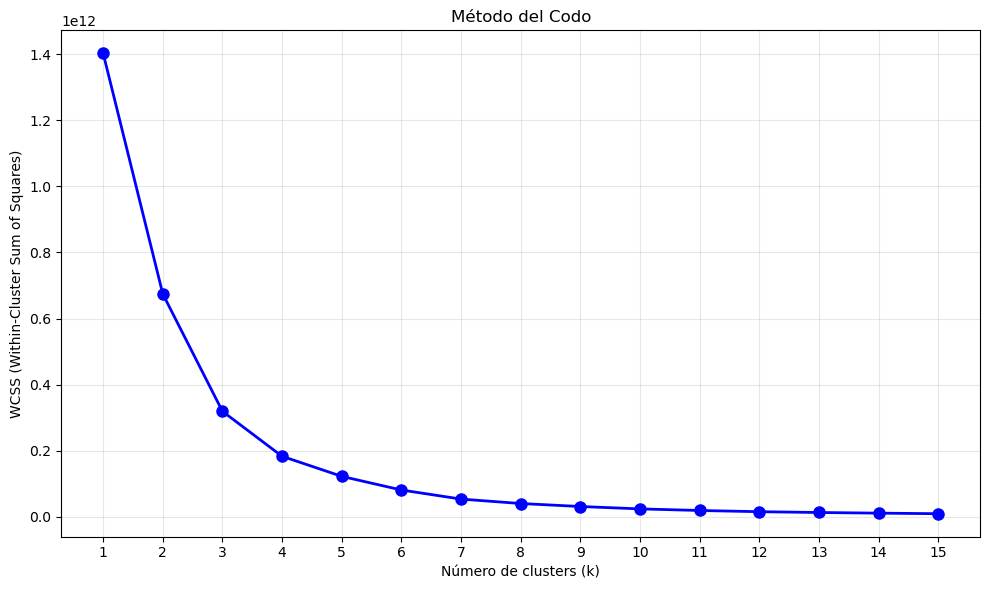

WCSS values for each k:
k=1: WCSS=1402708955376.06
k=2: WCSS=674303384062.24
k=3: WCSS=319090177763.64
k=4: WCSS=183045299720.20
k=5: WCSS=122283639845.25
k=6: WCSS=81000043031.71
k=7: WCSS=53506946716.44
k=8: WCSS=40068015199.54
k=9: WCSS=31029469676.88
k=10: WCSS=23836663120.17
k=11: WCSS=18960902946.45
k=12: WCSS=15326173789.33
k=13: WCSS=12896985632.47
k=14: WCSS=10947480683.56
k=15: WCSS=9247823345.86


In [ ]:
from sklearn.cluster import KMeans

df_kmeans = df.select_dtypes(include=[np.number]).dropna()

wcss = []
k_range = range(1, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_kmeans)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Método del Codo')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print("WCSS values for each k:")
for k, w in zip(k_range, wcss):
    print(f"k={k}: WCSS={w:.2f}")



<div style="border-style:groove;border-width:thin;padding:10px">
    <p>8. Implementa el método del codo con el dataset actual y anota el valor adecuado de k.</p>
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
9. Ahora implementa KMeans con el número obtenido anteriomente y guarda las etiquetas en una columna nueva del dataframe.
</div>

In [21]:
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_kmeans['Cluster'] = kmeans_final.fit_predict(df_kmeans)

df['Cluster'] = df_kmeans['Cluster']

print(f"KMeans applied with k={optimal_k}")
print(f"Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())
print("\nDataframe with clusters:")
df.head(10)

KMeans applied with k=3
Cluster distribution:
Cluster
0    1076
1    1136
2       1
Name: count, dtype: int64

Dataframe with clusters:


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Cluster
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,0,1,0,0,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,0,1,0,0,0,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,0,0,0,0,1,0,0,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,0,0,0,0,1,0,0,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,1,0,0,0,1,0,0,0,0,0
5,62513.0,0,1,16,520,42,98,0,42,14,...,0,0,0,0,0,0,1,0,0,0
6,55635.0,0,1,34,235,65,164,50,49,27,...,0,0,0,1,0,0,0,0,0,0
7,33454.0,1,0,32,76,10,56,3,1,23,...,1,0,0,0,1,0,0,0,0,1
8,30351.0,1,0,19,14,0,24,3,3,2,...,1,0,0,0,0,0,1,0,0,1
9,5648.0,1,1,68,28,0,6,1,1,13,...,1,0,0,0,0,0,1,0,0,1


<div style="border-style:groove;border-width:thin;padding:10px">
10. Crea un dataframe nuevo con los datos del original pero quédate solo con las columnas que tienen valores significativos para nosotros. Vamos a ver si encontramos relaciones entre los clientes de un cluster (el 0, por ejemplo). Pinta los valores del dataframe (por ejemplo, el nivel educativo, el estado civil, los ingresos, el número total de hijos, el número total de gasto y la edad) de los individuos de la clase 0. ¿Identificas alguna relación?
</div>